In [1]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from src.rset_opt import *
from FasterRisk.src.fasterrisk import fasterrisk
from gam_rs_utils.binarize_dataset import binarize_dataset
from gam_rs_utils.utils import *
from blocking_method.blocking import optimize_support

from time import time

dataset_settings = [
    ('bank', {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 1,
        "merge_bins": 19,
        'gap_tolerance': 0.006,
        'num_estimators': 50,
        'n_support_set': 15,
    }),
    ('compas', {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 11,
        'gap_tolerance': 0.0025,
        'num_estimators': 50,
        'n_support_set': 15,
    }),
    ("diabetes", {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 34,
        'gap_tolerance': 0.005,
        'num_estimators': 200,
        'n_support_set': 40,
    }),
    # 'netherlands': {
    #     "l0": 0.001,
    #     "l2": 0.5,
    #     "m": 0.01,
    #     'gap_tolerance': 0.0015,
    #     'num_estimators': 50,
    # },
    ('spambase', {
        "l0": 0.001,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 48,
        'gap_tolerance': 0.01,
        'num_estimators': 50,
        'n_support_set': 25,
    }),
    ('mimic2', {
        "l0": 0.0005,
        "l2": 0.001,
        "m": 1.01,
        "r_min": 0.1,
        "merge_bins": 35,
        'gap_tolerance':0.002,
        'num_estimators': 50,
        'n_support_set': 25,
    }),
]

In [17]:
for dname, settings in dataset_settings:
    n_estimators = settings["num_estimators"]
    
    dataset = pd.read_csv(f"datasets/{dname}.csv")
    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, n_estimators)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]
    header = pd.Index(["intercept"] + list(X.columns)).astype("object")
    X_one_hot, y = utils.get_X_y(X, y)

    print(X_one_hot.shape, y.shape)

(4521, 25) (4521,)
(6907, 22) (6907,)
(768, 50) (768,)
(4601, 30) (4601,)
(24508, 33) (24508,)


### Baseline GAM with Blocking

In [8]:
results = []
for dname, settings in dataset_settings:
    l0 = settings["l0"]
    l2 = settings["l2"]
    m = settings["m"]
    merge_bins = settings["merge_bins"]
    n_estimators = settings["num_estimators"]
    n_support_set = settings["n_support_set"]

    start = time()
    sparse_gam = prepare_sparse_gam(dname, l0, l2, m, n_estimators)
    baseline_gam = optimize_support(sparse_gam, n_support_set)
    end = time()
    # sparse_gam = f"models/{dname}_{l0}_{l2}_{m}.p"
    # baseline_gam = f"models/{dname}_{l0}_{l2}_{m}_merge_bins_{n_support_set}.p"

    with open(sparse_gam, "rb") as f:
        sparse_gam = pickle.load(f)
    with open(baseline_gam, 'rb') as f:
        baseline_gam = pickle.load(f)

    X = sparse_gam["X"]
    y = sparse_gam["y"]
    indices = baseline_gam["indices"]
    w_center_block = baseline_gam["w_center_block"]

    predictions = np.zeros((X.shape[0], len(indices)))
    w_samples = np.zeros((len(indices), len(sparse_gam["w_orig"])))
    for support in range(len(indices)):
        new_X = get_new_X(indices[support], X)
        w_sample = w_center_block[support]

        logit = new_X @ w_sample
        y_pred = np.exp(logit) / (1 + np.exp(logit))
        y_pred = np.where(y_pred > 0.5, 1, -1)
        predictions[:, support] = y_pred

        true_w_sample = get_true_w_sample(indices[support], w_sample)
        w_samples[support] = true_w_sample

    try:
        assert np.allclose(predictions, get_predictions(X, np.zeros(w_samples.shape[0]), w_samples))
    except AssertionError:
        print("predictions:")
        print(predictions)
        print("get_predictions output:")
        print(get_predictions(X, np.zeros(w_samples.shape[0]), w_samples))
        raise

    results.append({
        "dataset": dname,
        "w_samples": w_samples,
        "predictions": predictions,
        "runtime": end - start,
    })

with open(f"""analysis/results/methods/blocking.pkl""", "wb") as f:
    pickle.dump(results, f)

25
(4521, 25) (4521,)
(25,) hi
(25,) hi2
(4521, 25) (25,) (4521, 25) (25,)
objective: 0.2670624089684565 objective in LR 0.2670624089684565
m:1.01, log objective:0.2670624089684565, eps:0.26973303305814106
0.5501 0.26973303305814106
sample_p [1.         0.97190887 0.43397478 0.70714444 0.97080292 0.2057067
 0.2034948  0.13669542 0.0176952  0.0022119  0.02300376 0.05352798
 0.12541473 0.00464499 0.02809113 0.02565804 0.02322495 0.07122318
 0.02831232 0.00199071 0.81950896 0.17319177 0.81950896 0.06326034
 0.18049104]
delta_support = 10, new rsetbound = 0.27973303305814107, delta rsetbound = 0.01
----------- before optimization -----------
volume proportional to  tensor(6.1783e+30, dtype=torch.float64, grad_fn=<MulBackward0>)
0 tensor(0.0587, dtype=torch.float64, grad_fn=<AddBackward0>)
1 tensor(0.0586, dtype=torch.float64, grad_fn=<AddBackward0>)
2 tensor(0.0585, dtype=torch.float64, grad_fn=<AddBackward0>)
3 tensor(0.0584, dtype=torch.float64, grad_fn=<AddBackward0>)
4 tensor(0.0583, d

### Baseline Ellipsoid Sampling Followed by Zeroing

In [2]:
def hard_threshold(x, k_2):
    x = x.copy()
    small_indices = np.argsort(np.abs(x))[:k_2]
    x[small_indices] = 0
    return x

In [6]:
methods = [
    {"method": "uniform"},
    # {"method": "poisson", "max_attempts": 1000},
]

for method in methods:
    results = []
    for dname, settings in dataset_settings:
        l0 = settings["l0"]
        l2 = settings["l2"]
        m = settings["m"]
        num_estimators = settings["num_estimators"]
        if method["method"] == "poisson":
            method["r_min"] = settings["r_min"]
        filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)

        start = time()
        betas_fastSparse = prepare_sparse_gam(dname, l0, l2, m)
        w_samples = get_models_from_rset(filepath, n_samples=100, plot_shape=False, sample_from_surface=False, method=method)
        
        # w_samples_zeroed = np.zeros(w_samples.shape)
        # for i in range(len(w_samples)):
        #     w_samp = w_samples[i]
        #     w_samples_zeroed[i] = hard_threshold(w_samp, 0)
        # end = time()

        X = pickle.load(open(betas_fastSparse, 'rb'))['X']
        data = pd.read_csv("datasets/{}.csv".format(dname))
        y = data.iloc[:, -1].values
        y_max, y_min = np.max(y), np.min(y)
        y = -1 + 2 * (y - y_min) / (y_max - y_min)
        print(X.shape, y.shape)

        print("Loss: ", get_loss(X, y, np.zeros(w_samples.shape[0]), w_samples))
        # print("Loss: ", get_loss(X, y, np.zeros(w_samples_zeroed.shape[0]), w_samples_zeroed))

        results.append({
            "dataset": dname,
            "l0": l0,
            "l2": l2,
            "m": m,
            "w_samples": w_samples,
            "predictions": get_predictions(X, np.zeros(len(w_samples)), w_samples),
            # "runtime": end - start,
        })

    # with open(f"""analysis/results/methods/{method["method"]}.pkl""", "wb") as f:
    #     pickle.dump(results, f)

header dimension 3719
lamb0:0.001, lamb2:0.001, acc:0.9033399690333996, auc:0.88702783109405, supp_size:13
pair before removing {'housing': [0.0], 'loan': [0.0], 'contact': [1.0], 'month': [9.0], 'duration': [211.0, 348.0, 645.0, 770.0], 'pdays': [374.0], 'previous': [0.0, 1.0], 'poutcome': [1.0]}
k, v housing [0.0, 1]
k, v loan [0.0, 1]
k, v contact [1.0, 2]
k, v month [9.0, 11]
k, v duration [211.0, 348.0, 645.0, 770.0, 3025]
k, v pdays [374.0, 871]
k, v previous [0.0, 1.0, 25]
k, v poutcome [1.0, 3]
pair after removing {'housing': [0.0, 1], 'loan': [0.0, 1], 'contact': [1.0, 2], 'month': [9.0, 11], 'duration': [211.0, 348.0, 645.0, 770.0, 3025], 'pdays': [374.0, 871], 'previous': [0.0, 1.0, 25], 'poutcome': [1.0, 3]}
v_count: [0, 2, 2, 2, 2, 5, 2, 3, 2]
[ 0  2  4  6  8 13 15 18 20]
housing 0 0
housing 1 1
loan 0 2
loan 1 3
contact 0 4
contact 1 5
month 0 6
month 1 7
duration 0 8
duration 1 9
duration 2 10
duration 3 11
duration 4 12
pdays 0 13
pdays 1 14
previous 0 15
previous 1 16


KeyboardInterrupt: 

In [5]:
method = {"method": "uniform"}
dname = 'bank'
l0 = 0.001
l2 = 0.001
m = 1.01
r_min = 1

filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)
# betas_fastSparse = prepare_sparse_gam(dname, lamb0=l0, lamb2=l2, multiplier=m)
with open(filepath, 'rb') as f:
    betas_fastSparse = pickle.load(f)

print(len(betas_fastSparse['header_new']))
print(len(betas_fastSparse['header_orig']))
print(betas_fastSparse['header_new'])

21
3719
['intercept', 'housing<=0.0', '0.0<housing<=1', 'loan<=0.0', '0.0<loan<=1', 'contact<=1.0', '1.0<contact<=2', 'month<=9.0', '9.0<month<=11', 'duration<=211.0', '211.0<duration<=348.0', '348.0<duration<=645.0', '645.0<duration<=770.0', '770.0<duration<=3025', 'pdays<=374.0', '374.0<pdays<=871', 'previous<=0.0', '0.0<previous<=1.0', '1.0<previous<=25', 'poutcome<=1.0', '1.0<poutcome<=3']


### Quadratic Programming

In [2]:
dname = 'bank'
l0 = 0.001
l2 = 0.001
m = 1.01
r_min = 1

with open(f"{dname}_{l0}_{l2}_{m}.p", "rb") as f:
    res = pickle.load(f)

In [9]:
import cvxpy as cp

def in_ellipsoid(x, w_orig, H, eps):
    delta = x - w_orig
    val = delta.T @ H @ delta
    return val <= eps, val

def l1_sparse_ellipsoid_solution(H, w_orig, rset_bound, lam, ep=None):
    d = len(w_orig)
    x = cp.Variable(d)
    penalty = cp.norm1(x + ep) if ep is not None else cp.norm1(x)
    obj = cp.Minimize(lam * penalty)
    constraint = [cp.quad_form(x - w_orig, H) <= rset_bound]
    prob = cp.Problem(obj, constraint)
    prob.solve()
    return x.value

def hard_threshold(x, k_2):
    x = x.copy()
    small_indices = np.argsort(np.abs(x))[:k_2]
    x[small_indices] = 0
    return x

def l1_relaxation(H, w_orig, rset_bound, lam, k_2, X, y, n):
    samples = []
    for _ in range(n):
        ep = 0.1 * np.random.randn(len(w_orig))
        solutions = {"w_orig": w_orig}
        solutions['w_sol'] = l1_sparse_ellipsoid_solution(H, w_orig, rset_bound, lam, ep)
        solutions['hard_thresholded_w'] = hard_threshold(solutions['w_sol'], k_2)

        # for k, v in solutions.items():
        #     print(f"{k}: {v} {in_ellipsoid(v, w_orig, H, rset_bound)} {get_loss(X, y, np.zeros(1), np.array([v]))}")

        samples.append(solutions['hard_thresholded_w'])
        if not in_ellipsoid(solutions['hard_thresholded_w'], w_orig, H, rset_bound):
            print("Warning: solution not in ellipsoid!")
    return samples

# solutions = l1_relaxation(res['hessian'], res['w_orig'], res['rset_bound'] * 0.1, 0.001, 10, res['X'], res['y'], 100)
# solutions = np.array(solutions)
# solutions.shape

In [10]:
results = []
for dname, settings in dataset_settings:
    l0 = settings["l0"]
    l2 = settings["l2"]
    m = settings["m"]
    r_min = settings["r_min"]

    with open(f"{dname}_{l0}_{l2}_{m}.p", "rb") as f:
        sparse_gam = pickle.load(f)

    hessian = sparse_gam['hessian']
    w_orig = sparse_gam['w_orig']
    rset_bound = sparse_gam['rset_bound']
    X, y = sparse_gam['X'], sparse_gam['y']

    start = time()
    solutions = l1_relaxation(hessian, w_orig, rset_bound * 0.1, 0.001, 10, X, y, 100)
    end = time()

    betas = np.array(solutions)
    beta0 = np.zeros(len(betas))
    results.append({
        "dataset": dname,
        "runtime": end - start,
        "w_samples": solutions,
        "loss": get_loss(X, y, beta0, betas),
        "predictions": get_predictions(X, beta0, betas),
    })

with open(f"analysis/results/methods/l1_relaxation.pkl", "wb") as f:
    pickle.dump(results, f)


100%|██████████| 100/100 [00:00<00:00, 17427.61it/s]


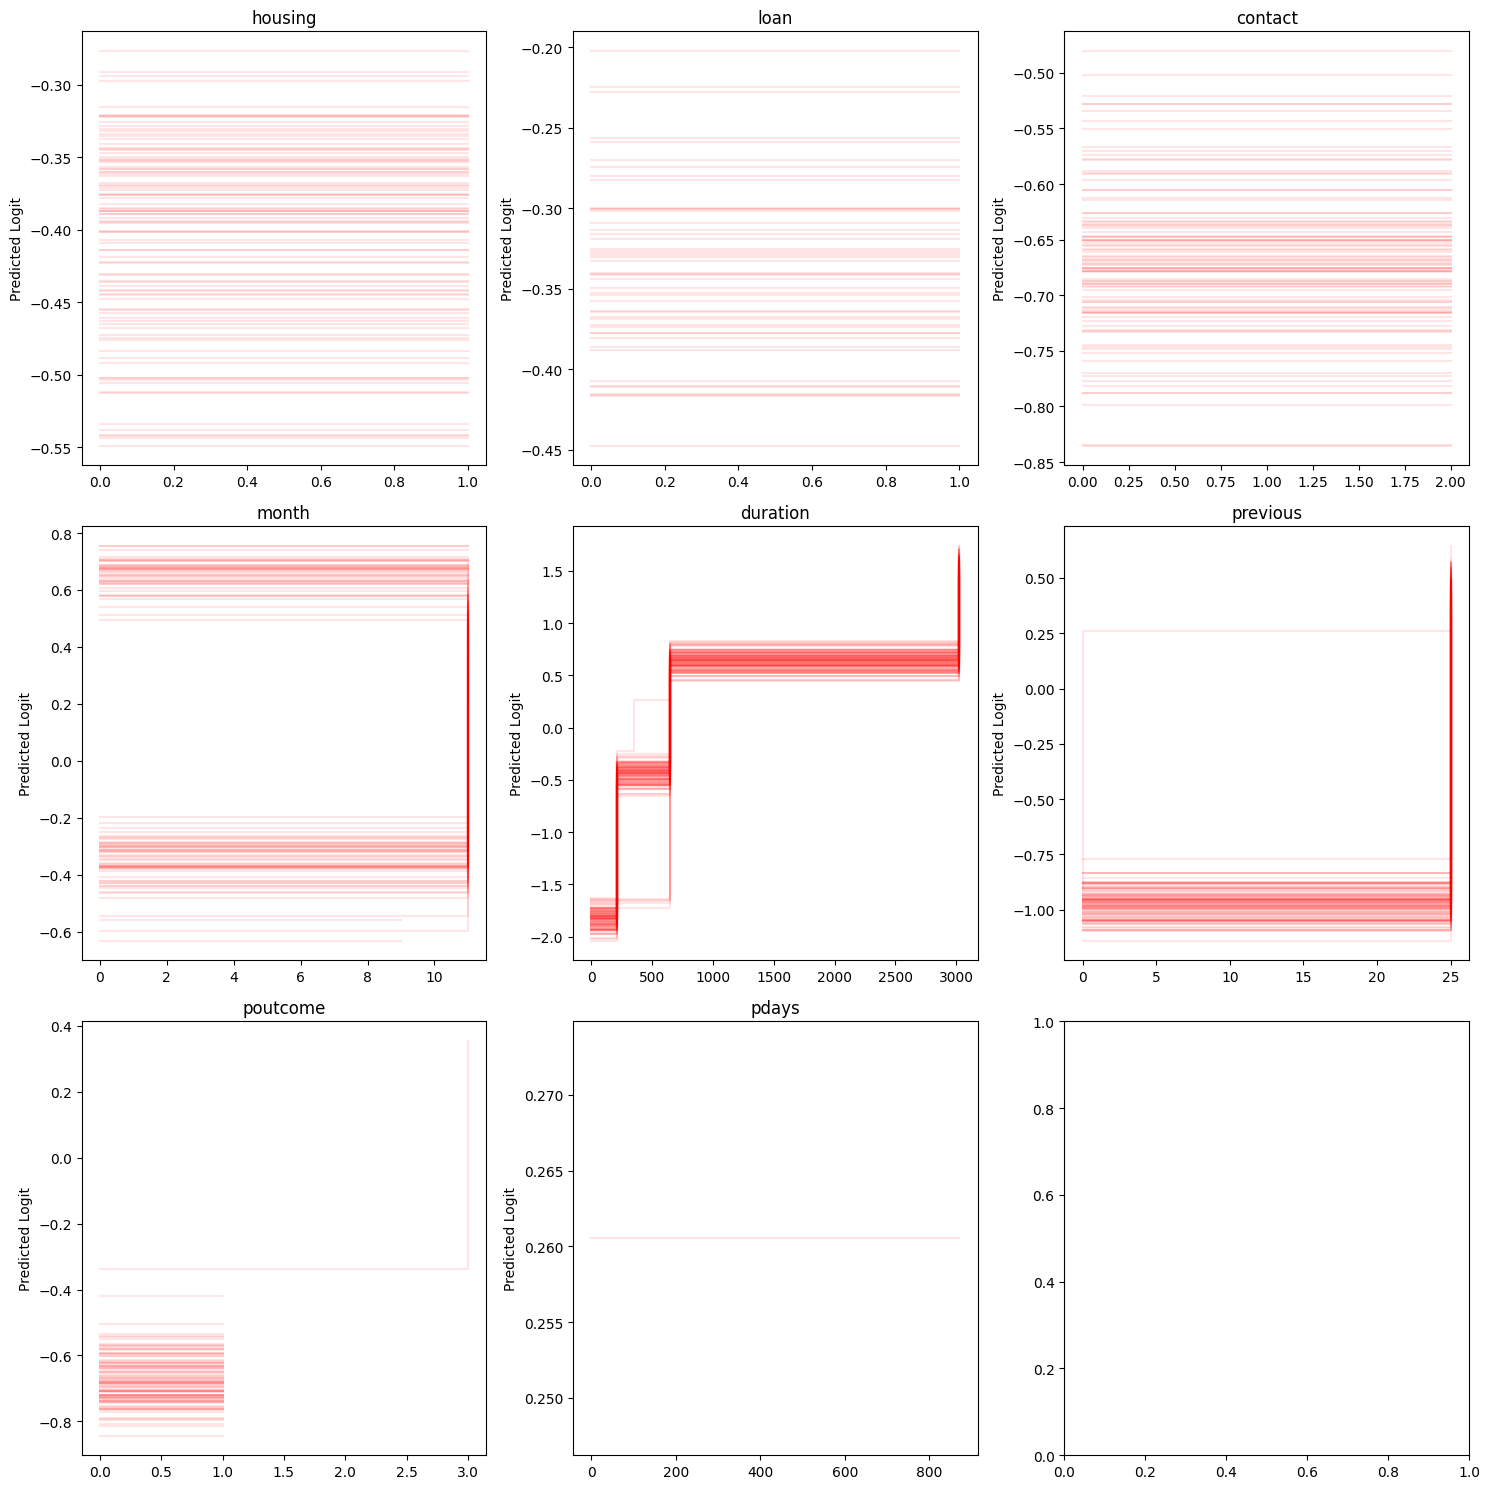

In [13]:
_ = plot_gam(np.array(res['header_new'][1:]), solutions[:, 1:])

### Swapping Method

In [2]:
results = []
for dataset_name, settings in dataset_settings:
    ne = settings["num_estimators"]
    gt = settings['gap_tolerance']
    n_support_set = settings['n_support_set']

    path = 'datasets/{}.csv'.format(dataset_name)
    dataset = pd.read_csv(path)
    print(f"Dataset: {dataset_name}")
    print(f"Binarized shape: {dataset.shape}")

    df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, ne)
    X, y = df.iloc[:, :-1], df.iloc[:, -1]
    header = pd.Index(["intercept"] + list(X.columns)).astype("object")
    X_one_hot, y = utils.get_X_y(X, y)

    start = time()
    rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=n_support_set, lb=-100, ub=100, gap_tolerance=gt, select_top_m=-1, maxAttempts=25)
    rs.optimize_with_swaps_beam_search(swaps=5, beam_size=100, verbose=True)
    end = time()

    print(f"\t{rs.sparseDiversePool_betas.shape[0]} solutions, {end - start:.2f} seconds")
    results.append({
        "dataset": dataset_name,
        "dataset_shape": dataset.shape,
        "num_estimators": ne,
        "gap_tolerance": gt,
        "threshold_guess_time": threshold_guess_time,
        "num_features": len(header),
        "runtime": end - start,
        "betas": rs.sparseDiversePool_betas,
        "beta0": rs.sparseDiversePool_beta0,
        "num_solutions": rs.sparseDiversePool_betas.shape[0],
        "loss": get_loss(X_one_hot, y, rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas),
        "predictions": get_predictions(X_one_hot, rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas),
    })

with open(f"analysis/results/methods/swap.pkl", "wb") as f:
    pickle.dump(results, f)

Dataset: bank
Binarized shape: (4521, 17)
swap 0, beam size 1
swap 1, beam size 49
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 345.76 seconds
Dataset: compas
Binarized shape: (6907, 8)
swap 0, beam size 1
swap 1, beam size 58
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 305.67 seconds
Dataset: diabetes
Binarized shape: (768, 9)
swap 0, beam size 1
swap 1, beam size 100
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 1143.19 seconds
Dataset: spambase
Binarized shape: (4601, 58)
swap 0, beam size 1
swap 1, beam size 38
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	74 solutions, 370.43 seconds
Dataset: mimic2
Binarized shape: (24508, 18)
swap 0, beam size 1
swap 1, beam size 63
swap 2, beam size 100
swap 3, beam size 100
swap 4, beam size 100
	100 solutions, 5016.70 seconds


### Comparison

In [ ]:
methods = ["blocking", "l1_relaxation", "swap"]
dataset_names = ["bank", "compas", "diabetes", "spambase", "mimic2"]

dname_list, method_list, losses, hamming = [], [], [], []
iou, euclidean, cosine = [], [], []
for dname in dataset_names:
    for method in methods:
        with open(f"analysis/results/methods/{method}.pkl", "rb") as f:
            results = pickle.load(f)
        df = pd.DataFrame(results)
        df = df[df["dataset"] == dname]

        for i, row in df.iterrows():
            predictions = row["predictions"]
            w_samples = row["w_samples"] if "w_samples" in row else row["betas"]
            w_samples = np.array(w_samples)

            dataset = pd.read_csv(f"datasets/{dname}.csv")
            df, _, _, _ = binarize_dataset(dataset, 50)
            X, y = df.iloc[:, :-1], df.iloc[:, -1]
            X_one_hot, y = utils.get_X_y(X, y)
            y_broadcasted = np.repeat(y[:, np.newaxis], predictions.shape[1], axis=1)

            loss_matrix = (predictions != y_broadcasted)
            dname_list.append(dname)
            method_list.append(method)
            losses.append(loss_matrix.mean())
            hamming.append(average_pairwise_diversity(predictions.T, hamming_distance, limit=100))

            iou.append(average_pairwise_diversity(w_samples, inverse_IoU, limit=100))
            euclidean.append(average_pairwise_diversity(w_samples, euclidean_distance, limit=100))
            cosine.append(average_pairwise_diversity(w_samples, inverse_cosine_similarity, limit=100))

results_df = pd.DataFrame({
    "dataset": dname_list,
    "method": method_list,
    "loss": losses,
    "hamming": hamming,
    "iou": iou,
    "euclidean": euclidean,
    "cosine": cosine
})

In [ ]:
plot_two_var_bar_2(results_df, "method", "loss")
plot_two_var_bar_2(results_df, "method", "hamming")
plot_two_var_bar_2(results_df, "method", "iou")
plot_two_var_bar_2(results_df, "method", "euclidean")
plot_two_var_bar_2(results_df, "method", "cosine")